# MODULE 6.1: UNSUPERVISED LEARNING

## Topics Covered
1. K-Means Clustering
2. Hierarchical Clustering
3. DBSCAN

---

## What is Unsupervised Learning? (Start Here)

> **Unsupervised Learning** = learning from data **without any labels**. The model has to find structure on its own. The main task we cover here is:
>
> - **Clustering** — group similar points together (sections 1–3 below).

**Simple Story for Clustering:**
Imagine you walk into a room of 100 strangers. Nobody tells you who is who. But after watching for a while, you naturally group them:

```
  Group 1: people standing near the food table
  Group 2: people dancing
  Group 3: people on phones in the corner
```

You used **similarity** (where they stand, what they do) to form groups. That is clustering.

**Supervised vs Unsupervised:**

| Supervised (Classification) | Unsupervised (Clustering) |
|---|---|
| Data has labels: `cat`, `dog` | Data has NO labels |
| Model learns to predict the label | Model learns structure (groups) |
| Example: spam vs ham | Example: customer segmentation |

In [15]:
# Setup — run once
# !pip install numpy pandas scikit-learn matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons

np.random.seed(42)
print('Setup done!')

Setup done!


### What this code does
- Imports **numpy** (math arrays), **pandas** (tables), **matplotlib** (plots).
- Imports `make_blobs` and `make_moons` from sklearn — these generate synthetic 2D datasets we'll use throughout.
- `np.random.seed(42)` fixes the random number generator so the results are the same every time you run the notebook.

---
# SECTION 1: K-MEANS CLUSTERING

## Definition
> **K-Means** is a clustering algorithm that splits data into **K groups** by repeatedly moving K "centers" (called **centroids**) to the average of the points nearest to them.

**In simple words:** Pick K points as group leaders. Each data point joins its nearest leader. Then each leader moves to the middle of its group. Repeat until nobody moves.

```
  Step 1: Drop K random centroids (★)
  Step 2: Each point → joins nearest ★
  Step 3: Each ★ moves to the average of its points
  Step 4: Repeat 2–3 until centroids stop moving
```

## Sub-Definitions

> **Centroid:** The center (mean) of a cluster — just the average of all points in that cluster.

> **K:** How many clusters you want. **You must choose K yourself.**

> **Euclidean Distance:** The straight-line distance between two points.
> $$d(p, q) = \sqrt{(p_1-q_1)^2 + (p_2-q_2)^2}$$

> **Inertia (WCSS):** Sum of squared distances from each point to its centroid. Lower = tighter clusters.

## The Algorithm in 4 Steps
```
1. INIT      → randomly place K centroids
2. ASSIGN    → for each point, find nearest centroid → join that cluster
3. UPDATE    → move each centroid to the mean of its assigned points
4. REPEAT    → step 2 and 3 until centroids no longer move (converged)
```

## Tiny Manual Example (6 points, K=2)

Let's cluster 6 points into 2 groups by hand.

```
Points:
  A=(1,1)   B=(1,2)   C=(2,1)     ← these look like one group (bottom-left)
  D=(8,8)   E=(9,8)   F=(8,9)     ← these look like another group (top-right)

Pick K=2 random centroids:
  C1 = (0,0)    C2 = (10,10)

ITERATION 1 — Assign each point to nearest centroid:
  A=(1,1): dist to C1 = √2 = 1.41,  to C2 = √162 = 12.7  → JOIN C1
  B=(1,2): dist to C1 = √5 = 2.24,  to C2 = √145 = 12.0  → JOIN C1
  C=(2,1): dist to C1 = √5 = 2.24,  to C2 = √145 = 12.0  → JOIN C1
  D=(8,8): dist to C1 = √128= 11.3, to C2 = √8   = 2.83  → JOIN C2
  E=(9,8): dist to C1 = √145= 12.0, to C2 = √5   = 2.24  → JOIN C2
  F=(8,9): dist to C1 = √145= 12.0, to C2 = √5   = 2.24  → JOIN C2

Update centroids = mean of their points:
  New C1 = mean(A,B,C) = ((1+1+2)/3, (1+2+1)/3) = (1.33, 1.33)
  New C2 = mean(D,E,F) = ((8+9+8)/3, (8+8+9)/3) = (8.33, 8.33)

ITERATION 2 — Reassign with new centroids: groups don't change.
  → CONVERGED ✓

Final clusters:
  Cluster 1: {A, B, C}   centroid (1.33, 1.33)
  Cluster 2: {D, E, F}   centroid (8.33, 8.33)
```

In [16]:
## STEP-BY-STEP: K-Means by hand (no sklearn) on the 6 points above
import numpy as np

# ── STEP 1: Our 6 points ─────────────────────────────────
points = np.array([
    [1,1], [1,2], [2,1],   # A, B, C  (bottom-left group)
    [8,8], [9,8], [8,9],   # D, E, F  (top-right group)
])
labels_str = ['A','B','C','D','E','F']
K = 2

# ── STEP 2: Pick 2 random initial centroids ──────────────
centroids = np.array([[0.0, 0.0], [10.0, 10.0]])
print('Initial centroids:'); print(centroids)

# ── STEP 3: Iterate ──────────────────────────────────────
for iteration in range(5):
    # 3a — for each point, distance to every centroid
    #      shape: (n_points, n_centroids)
    dists = np.linalg.norm(points[:, None] - centroids[None, :], axis=2)
    # 3b — assign each point to nearest centroid
    assignments = dists.argmin(axis=1)

    print(f'\nITERATION {iteration+1}')
    for i, lbl in enumerate(labels_str):
        print(f'  {lbl}={tuple(points[i])} → cluster {assignments[i]}  '
              f'(dists: {dists[i].round(2)})')

    # 3c — update centroids = mean of assigned points
    new_centroids = np.array([points[assignments == k].mean(axis=0) for k in range(K)])
    print(f'  New centroids:\n  {new_centroids.round(3)}')

    # 3d — converged? (centroids didn't move)
    if np.allclose(centroids, new_centroids):
        print('  → CONVERGED ✓')
        break
    centroids = new_centroids

print('\nFinal clusters:')
for k in range(K):
    members = [labels_str[i] for i in range(len(points)) if assignments[i]==k]
    print(f'  Cluster {k}: {members}  centroid={centroids[k].round(2)}')

Initial centroids:
[[ 0.  0.]
 [10. 10.]]

ITERATION 1
  A=(1, 1) → cluster 0  (dists: [ 1.41 12.73])
  B=(1, 2) → cluster 0  (dists: [ 2.24 12.04])
  C=(2, 1) → cluster 0  (dists: [ 2.24 12.04])
  D=(8, 8) → cluster 1  (dists: [11.31  2.83])
  E=(9, 8) → cluster 1  (dists: [12.04  2.24])
  F=(8, 9) → cluster 1  (dists: [12.04  2.24])
  New centroids:
  [[1.333 1.333]
 [8.333 8.333]]

ITERATION 2
  A=(1, 1) → cluster 0  (dists: [ 0.47 10.37])
  B=(1, 2) → cluster 0  (dists: [0.75 9.69])
  C=(2, 1) → cluster 0  (dists: [0.75 9.69])
  D=(8, 8) → cluster 1  (dists: [9.43 0.47])
  E=(9, 8) → cluster 1  (dists: [10.16  0.75])
  F=(8, 9) → cluster 1  (dists: [10.16  0.75])
  New centroids:
  [[1.333 1.333]
 [8.333 8.333]]
  → CONVERGED ✓

Final clusters:
  Cluster 0: ['A', 'B', 'C']  centroid=[1.33 1.33]
  Cluster 1: ['D', 'E', 'F']  centroid=[8.33 8.33]


### What this code does
- **Step 1**: Stores the 6 points (A–F) as a NumPy array.
- **Step 2**: Picks two starting centroids `(0,0)` and `(10,10)` — deliberately bad so we can see them move.
- **Step 3 (the loop)**:
  - `points[:, None] - centroids[None, :]` uses NumPy broadcasting to compute *every point minus every centroid* in one shot. Result shape: `(6 points, 2 centroids, 2 dims)`.
  - `np.linalg.norm(..., axis=2)` collapses the last axis into a single distance per (point, centroid) pair → shape `(6, 2)`.
  - `argmin(axis=1)` picks the **nearest centroid index** for each point.
  - `points[assignments == k].mean(axis=0)` computes each cluster's new centroid as the mean of its points.
  - `np.allclose(...)` checks if centroids stopped moving → that's convergence.
- Exits early when nothing changes between iterations.

In [17]:
## Same thing with sklearn (1 line of work)
from sklearn.cluster import KMeans

points = np.array([[1,1],[1,2],[2,1],[8,8],[9,8],[8,9]])

km = KMeans(n_clusters=2, n_init=10, random_state=42)
labels = km.fit_predict(points)

print('Labels:    ', labels)              # which cluster each point belongs to
print('Centroids: ', km.cluster_centers_.round(2))
print('Inertia:   ', round(km.inertia_, 3))  # total squared distance to centroids

Labels:     [1 1 1 0 0 0]
Centroids:  [[8.33 8.33]
 [1.33 1.33]]
Inertia:    2.667


### What this code does
- `KMeans(n_clusters=2, n_init=10, random_state=42)` — sklearn's K-Means.
  - `n_clusters=2` → K = 2.
  - `n_init=10` → run K-Means 10 times with different random starts and keep the best (lowest inertia). This protects against bad initial centroids.
  - `random_state=42` → reproducible results.
- `fit_predict(points)` does both: trains the model AND returns the cluster label for each point.
- `km.cluster_centers_` → the final centroid coordinates.
- `km.inertia_` → total squared distance from each point to its centroid (lower = tighter clusters).

## How to Choose K? — The Elbow Method

> **Elbow Method:** Run K-Means for K = 1, 2, 3, ... 10. For each, compute **inertia** (total squared distance to centroid). Plot it. The "elbow" — where the curve bends sharply — is a good K.

```
Inertia ↓
  |   ●
  |    ●
  |     ●
  |      ●  ← ELBOW (K=3 here) — adding more clusters barely helps
  |       ●─●─●─●─●
  +────────────────→ K
      1  2  3  4  5  6  7
```

**Why?** More clusters always = lower inertia (in the extreme, K = N points → inertia = 0). The elbow is where extra clusters stop adding much value.

K=1: inertia = 19710.6
K=2: inertia = 9125.8
K=3: inertia = 1840.9
K=4: inertia = 277.5
K=5: inertia = 251.0
K=6: inertia = 229.0
K=7: inertia = 203.4
K=8: inertia = 178.4


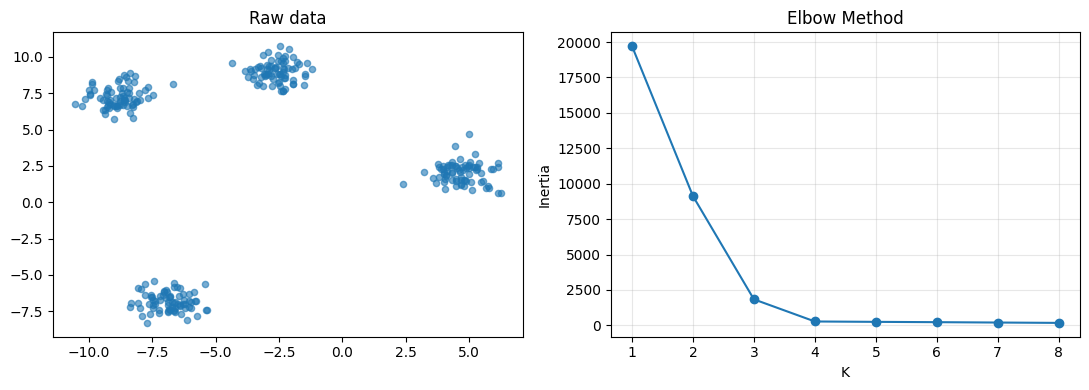


→ Big drop until K=4, then it flattens. Elbow at K=4 ✓


In [18]:
## Elbow Method on a real(ish) dataset
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate 4 clearly separated blobs
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)

inertias = []
Ks = range(1, 9)
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    print(f'K={k}: inertia = {km.inertia_:.1f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X[:,0], X[:,1], s=20, alpha=0.6); ax[0].set_title('Raw data')
ax[1].plot(Ks, inertias, 'o-'); ax[1].set_xlabel('K'); ax[1].set_ylabel('Inertia')
ax[1].set_title('Elbow Method'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\n→ Big drop until K=4, then it flattens. Elbow at K=4 ✓')

### What this code does
- `make_blobs(n_samples=300, centers=4, ...)` generates 300 fake 2D points grouped into 4 blobs — a perfect playground.
- The loop runs K-Means for K = 1, 2, … 8 and saves each run's `inertia_`.
- Left plot shows the raw data; right plot shows inertia vs K — the **elbow** at K=4 is where adding more clusters stops paying off.
- Reading the curve: huge drops from K=1→4, then it flattens. That bend = correct K.

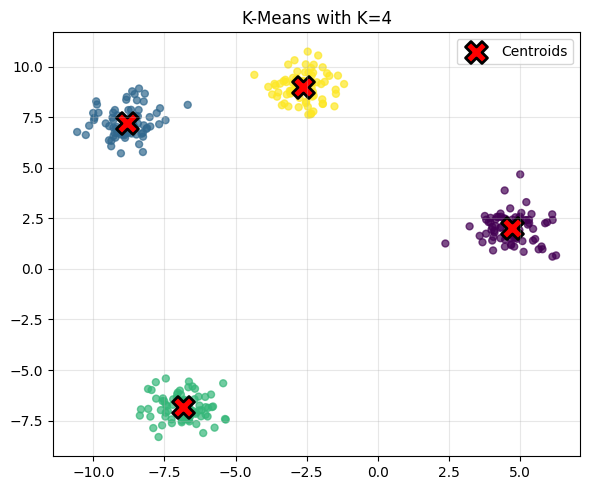

In [19]:
## Visualise the actual K-Means clusters at K=4
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X)
labels    = km.labels_
centroids = km.cluster_centers_

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=25, alpha=0.7)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=250,
            edgecolors='black', linewidths=2, label='Centroids')
plt.title('K-Means with K=4'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### What this code does
- Refits K-Means with K=4 (the elbow value).
- `c=labels` colours each point by its cluster.
- The red **X** markers are the centroids — the "average position" of each cluster.
- This is the visual proof that K-Means actually found the 4 blobs.

## K-Means Pros & Cons

| ✅ Pros | ❌ Cons |
|---|---|
| Fast and simple | Must choose K in advance |
| Scales to large data | Only finds **spherical/round** clusters |
| Easy to interpret (centroids) | Sensitive to outliers (mean is pulled) |
| Works well when clusters are well-separated | Bad initialisation → bad result (use `n_init`) |

**When K-Means fails:**
```
  ●●●●●●●          ●●●●●●●        K-Means will cut these in half
  ●     ●          ●     ●        because they're not spherical.
  ●     ●          ●     ●        → use DBSCAN instead.
  ●●●●●●●          ●●●●●●●
```

> **Reference:** [GeeksForGeeks — K-Means Clustering](https://www.geeksforgeeks.org/k-means-clustering-introduction/)

---
# SECTION 2: HIERARCHICAL CLUSTERING

## Definition
> **Hierarchical Clustering** builds a **tree of clusters** by repeatedly merging the two closest clusters (bottom-up) or splitting (top-down). The output is a **dendrogram** — a tree showing how points group together at every level.

**In simple words:** Start with every point as its own cluster. Find the two closest clusters → merge them. Repeat until everything is one big cluster. Then "cut" the tree at any height to get K clusters.

```
  Start: 5 separate points
    A   B   C   D   E

  A and B are closest → merge → {AB}
    {AB}   C   D   E

  D and E are closest → merge → {DE}
    {AB}   C   {DE}

  {DE} and C are closest → merge → {CDE}
    {AB}   {CDE}

  Final merge → {ABCDE}
```

## Sub-Definitions

> **Agglomerative (bottom-up):** Start with N clusters of 1 point each. Keep merging. (This is the common version.)

> **Divisive (top-down):** Start with 1 big cluster. Keep splitting. (Rarely used — slow.)

> **Dendrogram:** A tree diagram showing every merge. Y-axis = distance at which the merge happened.

> **Linkage:** The rule for measuring distance between two clusters (not just two points):

| Linkage | Distance between cluster A and B = ... |
|---|---|
| **Single** | distance between the **closest** pair of points |
| **Complete** | distance between the **farthest** pair of points |
| **Average** | **average** distance over all pairs |
| **Ward** | merge that increases variance the **least** (most popular) |

## Tiny Manual Example (5 points, single linkage)

```
Points (1D for simplicity):
  A = 1     B = 2     C = 5     D = 8     E = 9

Initial pairwise distances (just |x - y|):
        A   B   C   D   E
    A   0   1   4   7   8
    B   1   0   3   6   7
    C   4   3   0   3   4
    D   7   6   3   0   1
    E   8   7   4   1   0

Step 1 — smallest distance = 1 (A↔B and D↔E tie). Merge A,B first → {AB}.
Step 2 — recompute distances of {AB} to others (single linkage = min):
  d({AB}, C) = min(d(A,C), d(B,C)) = min(4,3) = 3
  d({AB}, D) = min(7,6) = 6
  d({AB}, E) = min(8,7) = 7
Step 3 — smallest now = 1 (D↔E). Merge → {DE}.
Step 4 — d({DE}, C) = min(3,4) = 3,  d({DE}, {AB}) = min(6,7,7,8) = 6.
         smallest = 3 (tie: {AB}↔C and {DE}↔C). Merge C with {DE} → {CDE}.
Step 5 — final merge of {AB} and {CDE} at distance 3.

Dendrogram (height = merge distance):

  height
    3 ──────┬─────────┐
    3      │       ┌──┴──┐
    1      │       │     ├──┐
    1   ┌──┴──┐    │     │  │
        A     B    C     D  E

Cut at height 2 → 3 clusters: {A,B}, {C}, {D,E}
Cut at height 4 → 2 clusters: {A,B}, {C,D,E}
```

Linkage matrix (each row = one merge):
  [cluster_i, cluster_j, distance, num_points_in_new_cluster]
[[0. 1. 1. 2.]
 [3. 4. 1. 2.]
 [2. 5. 3. 3.]
 [6. 7. 3. 5.]]


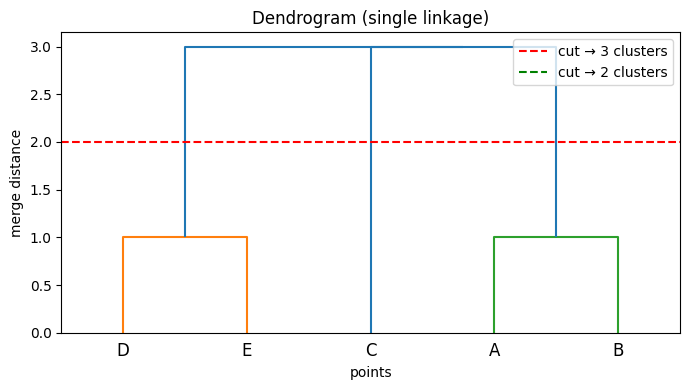


3-cluster cut: {'A': 2, 'B': 2, 'C': 3, 'D': 1, 'E': 1}
2-cluster cut: {'A': 1, 'B': 1, 'C': 1, 'D': 1, 'E': 1}


In [20]:
## Hierarchical clustering on the 5-point example with scipy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np
import matplotlib.pyplot as plt

points = np.array([[1],[2],[5],[8],[9]])  # 1D points
labels = ['A','B','C','D','E']

# linkage matrix — each row = (cluster_i, cluster_j, distance, size)
Z = linkage(points, method='single')
print('Linkage matrix (each row = one merge):')
print('  [cluster_i, cluster_j, distance, num_points_in_new_cluster]')
print(Z)

# Plot the dendrogram
plt.figure(figsize=(7,4))
dendrogram(Z, labels=labels)
plt.title('Dendrogram (single linkage)')
plt.xlabel('points'); plt.ylabel('merge distance')
plt.axhline(y=2, c='red', ls='--', label='cut → 3 clusters')
plt.axhline(y=4, c='green', ls='--', label='cut → 2 clusters')
plt.legend(); plt.tight_layout(); plt.show()

# Cut the tree to get K clusters
clusters_k3 = fcluster(Z, t=3, criterion='maxclust')
clusters_k2 = fcluster(Z, t=2, criterion='maxclust')
print(f'\n3-cluster cut: {dict(zip(labels, clusters_k3))}')
print(f'2-cluster cut: {dict(zip(labels, clusters_k2))}')

### What this code does
- `linkage(points, method='single')` builds the merge history. Each row of `Z` is one merge step:
  - `[cluster_i, cluster_j, distance, num_points_in_new_cluster]`.
  - At step 0 the indices are original points (0–4); after that, new cluster ids start at 5, 6, …
- `dendrogram(Z)` draws the tree — height of each merge = distance at which it happened.
- The two `axhline` lines show what happens if you "cut" the tree at different heights — different K.
- `fcluster(Z, t=K, criterion='maxclust')` cuts the tree to give exactly K clusters.

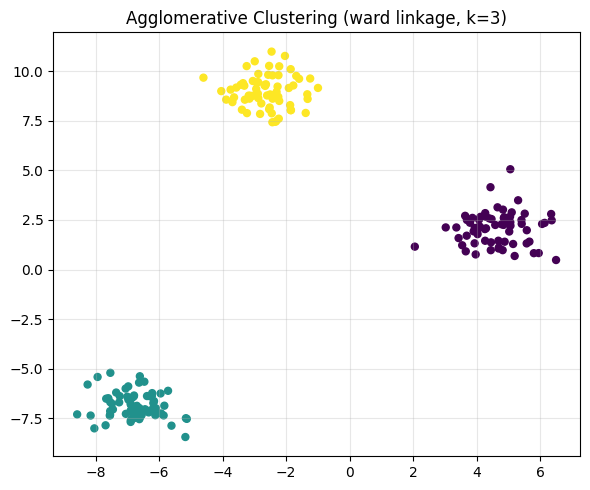

In [21]:
## Same thing with sklearn (Agglomerative Clustering)
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=42)

# Choose linkage (ward = default, most popular for Euclidean)
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=25)
plt.title('Agglomerative Clustering (ward linkage, k=3)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### What this code does
- `AgglomerativeClustering(n_clusters=3, linkage='ward')` — sklearn's hierarchical clusterer.
  - `linkage='ward'` minimises within-cluster variance at each merge — gives balanced, compact clusters.
- `fit_predict(X)` returns a cluster label for each of the 300 points.
- Sklearn's version doesn't expose the dendrogram directly — use scipy (previous cell) for that.

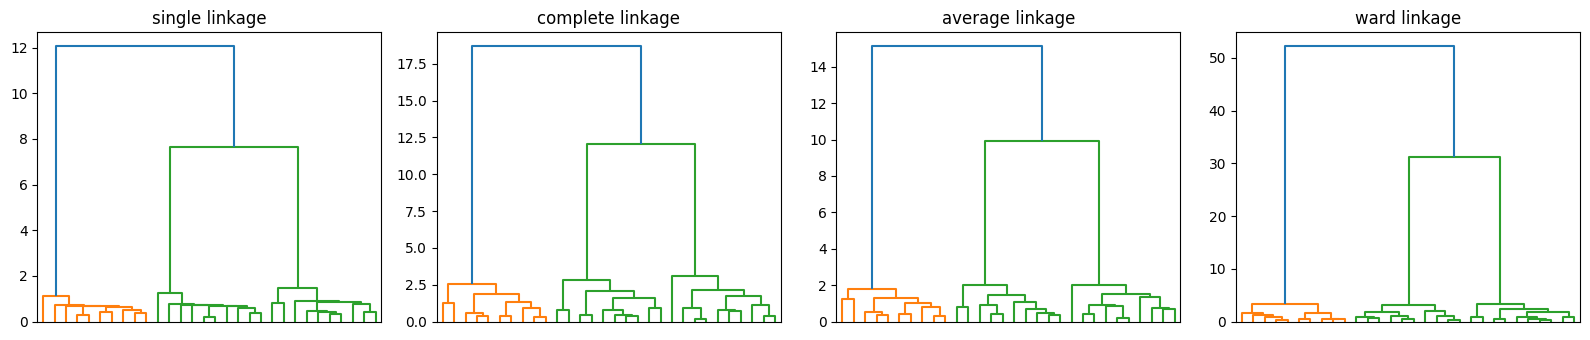

Tip:
  single   → tends to make long "chain" clusters
  complete → tight, compact clusters
  average  → middle ground
  ward     → balanced, equal-size clusters (most used)


In [22]:
## Compare the 4 linkage methods on the same data
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=30, centers=3, cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, method in zip(axes, ['single','complete','average','ward']):
    Z = linkage(X, method=method)
    dendrogram(Z, ax=ax, no_labels=True)
    ax.set_title(f'{method} linkage')
plt.tight_layout(); plt.show()

print('Tip:')
print('  single   → tends to make long "chain" clusters')
print('  complete → tight, compact clusters')
print('  average  → middle ground')
print('  ward     → balanced, equal-size clusters (most used)')

### What this code does
- Builds 4 dendrograms on the **same dataset** with different linkage rules: `single`, `complete`, `average`, `ward`.
- Things to notice in the plots:
  - **single** — long stringy chains; sensitive to noise.
  - **complete** — tall, balanced trees; tight clusters.
  - **average** — middle of the road.
  - **ward** — most balanced, equal-size groups (recommended default).

## Hierarchical Pros & Cons

| ✅ Pros | ❌ Cons |
|---|---|
| No need to pick K upfront — cut later | Slow on big data: O(n²) memory, O(n³) time |
| Dendrogram is easy to interpret | Sensitive to outliers and noise |
| Works for any distance metric | Once merged, can't undo (greedy) |
| Discovers nested groupings | Hard to scale beyond ~10K points |

**When to use it:** small/medium datasets, when you want to *see* the structure (e.g. gene expression, customer hierarchy, document trees).

> **Reference:** [GeeksForGeeks — Hierarchical Clustering](https://www.geeksforgeeks.org/hierarchical-clustering/)

---
# SECTION 3: DBSCAN

## Definition
> **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points that are **packed closely together** and marks lonely points as **noise/outliers**. It does **not** need K, and it can find any-shape clusters (rings, moons, blobs).

**In simple words:** A cluster is a region where many points are close to each other. Points in a low-density area are marked as noise, not forced into a cluster.

```
  ●●●●●●         ●●●●●●          ●     ← outliers (noise)
  ●●●●●●         ●●●●●●               
  ●●●●●●         ●●●●●●          ●  
    Cluster 1     Cluster 2      Noise
```

## Sub-Definitions (the 2 hyperparameters)

> **eps (ε):** The neighbourhood radius. "How close is *close*?"

> **min_samples:** Minimum points needed inside a point's eps-ball to call it dense.

> **Core point:** A point that has **≥ min_samples** neighbours within eps. (It sits in a dense area.)

> **Border point:** A point that is *inside* a core point's neighbourhood but doesn't itself have enough neighbours to be core.

> **Noise point:** A point that is neither core nor border. Stays unassigned (label `-1`).

```
  ◎ = core  (≥ min_samples neighbours within eps)
  ○ = border (touches a core, but few neighbours of its own)
  ✗ = noise  (alone)

       ◎─◎─◎
      /   |
     ◎    ○        ✗     ← noise
      \  /
       ◎
```

## The Algorithm in 3 Steps
```
1. For each point, count neighbours within distance eps.
2. If count ≥ min_samples → mark as CORE.
3. Connect cores that are within eps of each other into clusters.
   Border points join the nearest core's cluster.
   Everything else → noise (label = -1).
```

## Tiny Manual Example (8 points, eps=1.5, min_samples=3)

```
Points:
  P1=(1,1)  P2=(1,2)  P3=(2,1)  P4=(2,2)   ← packed cluster, bottom-left
  P5=(8,8)  P6=(8,9)  P7=(9,8)             ← packed cluster, top-right
  P8=(5,5)                                  ← lonely middle point

Settings: eps = 1.5,  min_samples = 3

Step 1 — for each point, count neighbours within eps=1.5
         (a point counts itself):

  P1's neighbours: P1,P2,P3,P4 → 4 neighbours ≥ 3 → CORE ◎
  P2's neighbours: P1,P2,P3,P4 → 4 → CORE ◎
  P3's neighbours: P1,P2,P3,P4 → 4 → CORE ◎
  P4's neighbours: P1,P2,P3,P4 → 4 → CORE ◎
  P5's neighbours: P5,P6,P7    → 3 → CORE ◎
  P6's neighbours: P5,P6,P7    → 3 → CORE ◎
  P7's neighbours: P5,P6,P7    → 3 → CORE ◎
  P8's neighbours: P8 only     → 1 → NOT core, no core nearby → NOISE ✗

Step 2 — connect cores within eps:
  P1,P2,P3,P4 all connect → Cluster 0
  P5,P6,P7    all connect → Cluster 1
  P8 alone               → Noise (label = -1)

Result:
  Cluster 0 = {P1,P2,P3,P4}
  Cluster 1 = {P5,P6,P7}
  Noise     = {P8}

Notice: we never told DBSCAN K=2. It figured it out on its own.
        It also flagged P8 as noise instead of forcing it into a cluster.
```

In [23]:
## DBSCAN on the 8-point example
from sklearn.cluster import DBSCAN
import numpy as np

points = np.array([
    [1,1],[1,2],[2,1],[2,2],   # P1-P4 dense cluster
    [8,8],[8,9],[9,8],         # P5-P7 dense cluster
    [5,5],                      # P8 lonely
])

db = DBSCAN(eps=1.5, min_samples=3).fit(points)
labels = db.labels_   # -1 = noise, 0 = first cluster, 1 = second, ...

for i, (pt, lbl) in enumerate(zip(points, labels)):
    tag = 'NOISE' if lbl == -1 else f'cluster {lbl}'
    print(f'  P{i+1} = {tuple(pt)} → {tag}')

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = list(labels).count(-1)
print(f'\nClusters found: {n_clusters},  Noise points: {n_noise}')

  P1 = (1, 1) → cluster 0
  P2 = (1, 2) → cluster 0
  P3 = (2, 1) → cluster 0
  P4 = (2, 2) → cluster 0
  P5 = (8, 8) → cluster 1
  P6 = (8, 9) → cluster 1
  P7 = (9, 8) → cluster 1
  P8 = (5, 5) → NOISE

Clusters found: 2,  Noise points: 1


### What this code does
- `DBSCAN(eps=1.5, min_samples=3)` — neighbourhood radius `1.5`, need 3 neighbours to be a core point.
- `db.labels_` returns a label for each point. Special label `-1` = **noise** (outlier).
- The loop prints each point's verdict — notice P8 in the middle gets `-1` because no other point is within radius 1.5.
- `n_clusters` counts unique labels excluding `-1`.

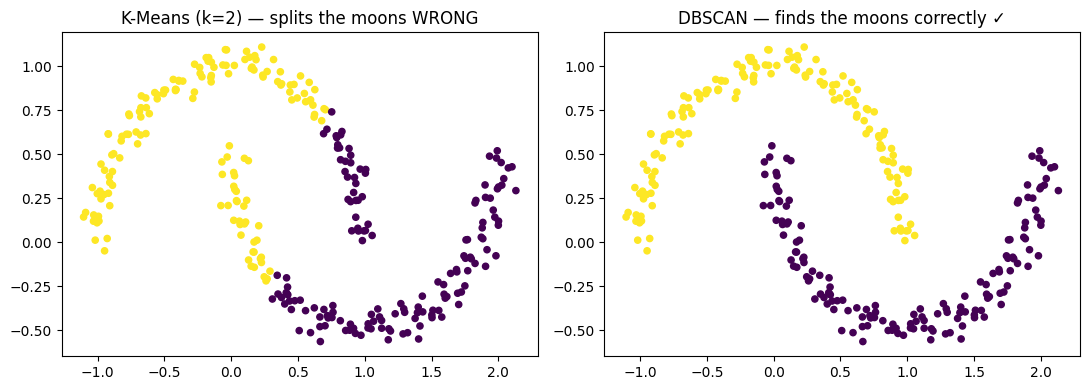

K-Means assumes round clusters → cuts each moon in half.
DBSCAN follows the *density* → traces the moon shape exactly.


In [24]:
## Where DBSCAN shines: non-spherical shapes (two moons)
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

km_labels  = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X)
dbs_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X[:,0], X[:,1], c=km_labels, cmap='viridis', s=20)
ax[0].set_title('K-Means (k=2) — splits the moons WRONG')
ax[1].scatter(X[:,0], X[:,1], c=dbs_labels, cmap='viridis', s=20)
ax[1].set_title('DBSCAN — finds the moons correctly ✓')
plt.tight_layout(); plt.show()

print('K-Means assumes round clusters → cuts each moon in half.')
print('DBSCAN follows the *density* → traces the moon shape exactly.')

### What this code does
- `make_moons(n_samples=300, noise=0.05)` generates two interlocking crescent shapes — the classic test for non-spherical clustering.
- Runs both K-Means (K=2) and DBSCAN on the same data.
- **Why K-Means fails:** it assumes round clusters → cuts each moon vertically through the middle.
- **Why DBSCAN works:** it follows the *density chain* of points → it can wrap around the curve of each moon.

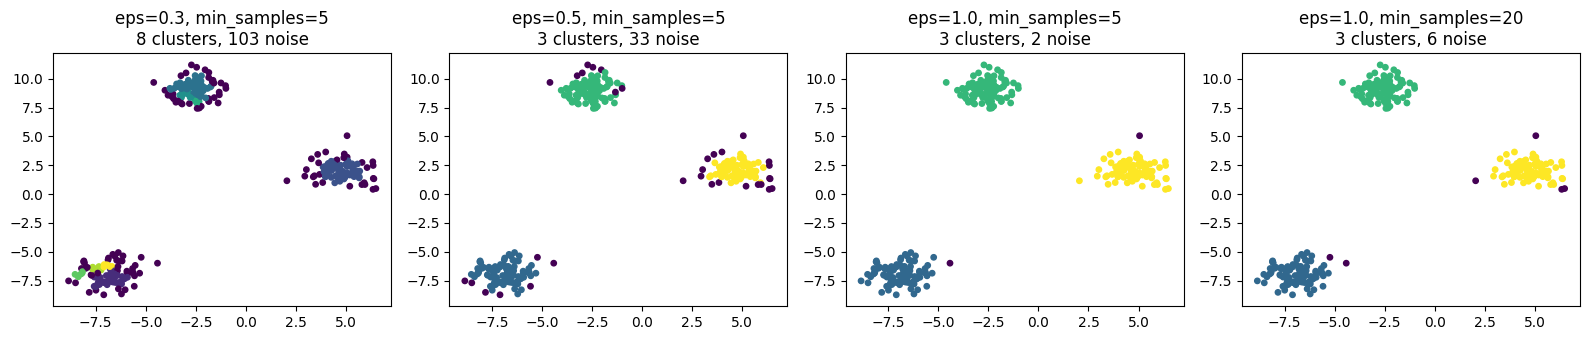

Reading the plots:
  Small eps  → many tiny clusters + lots of noise
  Big   eps  → everything merges into 1 cluster
  High min_samples → harder to be "core" → more noise


In [25]:
## Effect of eps and min_samples
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

params = [(0.3, 5), (0.5, 5), (1.0, 5), (1.0, 20)]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (eps, ms) in zip(axes, params):
    labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = list(labels).count(-1)
    ax.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=15)
    ax.set_title(f'eps={eps}, min_samples={ms}\n'
                 f'{n_clusters} clusters, {n_noise} noise')
plt.tight_layout(); plt.show()

print('Reading the plots:')
print('  Small eps  → many tiny clusters + lots of noise')
print('  Big   eps  → everything merges into 1 cluster')
print('  High min_samples → harder to be "core" → more noise')

### What this code does
- Runs DBSCAN with 4 different `(eps, min_samples)` combos to show how sensitive it is to these params.
- For each panel, counts: number of clusters found and number of noise points.
- Pattern to learn:
  - **eps too small** → almost everything is noise, many tiny clusters.
  - **eps too big** → all clusters merge into one giant blob.
  - **min_samples too high** → harder to qualify as core → more noise.

## Picking eps — the k-distance plot trick

> **k-distance plot:** For each point, find the distance to its k-th nearest neighbour (typically `k = min_samples`). Sort these distances and plot. The "elbow" suggests a good `eps`.

```
  k-distance ↓
    |              ●●
    |             ●
    |           ●           ← elbow → eps ≈ this value
    |       ●●●
    | ●●●●●
    +─────────────────→ points sorted by distance
```

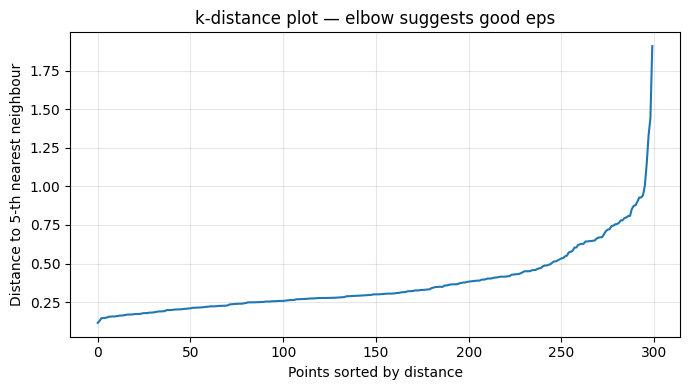

Look for the bend in the curve — that y-value is a sensible eps.


In [26]:
## k-distance plot to choose eps
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

k = 5  # = min_samples
nn = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nn.kneighbors(X)

kth_dist = np.sort(distances[:, -1])  # distance to k-th neighbour, sorted

plt.figure(figsize=(7,4))
plt.plot(kth_dist)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {k}-th nearest neighbour')
plt.title('k-distance plot — elbow suggests good eps')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'Look for the bend in the curve — that y-value is a sensible eps.')

### What this code does
- For each point, finds its `k`-th nearest neighbour distance (here `k = 5 = min_samples`).
- Sorts these distances and plots them.
- The **elbow** of the curve = a good `eps`. Below the elbow are points sitting in dense areas; above it are sparse/outlier points.
- This is the principled way to pick `eps` instead of guessing.

## DBSCAN Pros & Cons

| ✅ Pros | ❌ Cons |
|---|---|
| No K to choose | Two new params: `eps` and `min_samples` |
| Finds any-shape clusters (moons, rings) | Struggles when clusters have very different densities |
| Detects outliers automatically | Hard in high dimensions (distance becomes meaningless) |
| Robust to noise | Border points can be assigned non-deterministically |

**When to use it:** geographic data, anomaly detection, image segmentation, anything where "how dense?" matters more than "how round?".

> **Reference:** [GeeksForGeeks — DBSCAN](https://www.geeksforgeeks.org/dbscan-clustering-in-ml-density-based-clustering/)

---
# QUICK COMPARISON

## Clustering algorithms

| Feature | K-Means | Hierarchical | DBSCAN |
|---|---|---|---|
| Need to pick K? | YES (upfront) | No (cut tree later) | No |
| Cluster shape | Spherical only | Any (depends on linkage) | Any |
| Handles noise/outliers | No (forces every point in) | No | YES (label `-1`) |
| Speed on big data | Fast ⚡⚡⚡ | Slow (O(n²)) | Medium |
| Output | Labels + centroids | Labels + dendrogram | Labels (some `-1`) |
| Best for | Round, well-separated blobs | Small data, nested structure | Any-shape, noisy data |

## How to choose a clustering method?
```
  Do you know K?  ─── YES ──── clusters round? ── YES → K-Means
                                      └── NO  → DBSCAN
       │
       NO
       │
  Big dataset?  ── YES → DBSCAN
       │
       NO → Hierarchical (you'll see structure in the dendrogram)
```

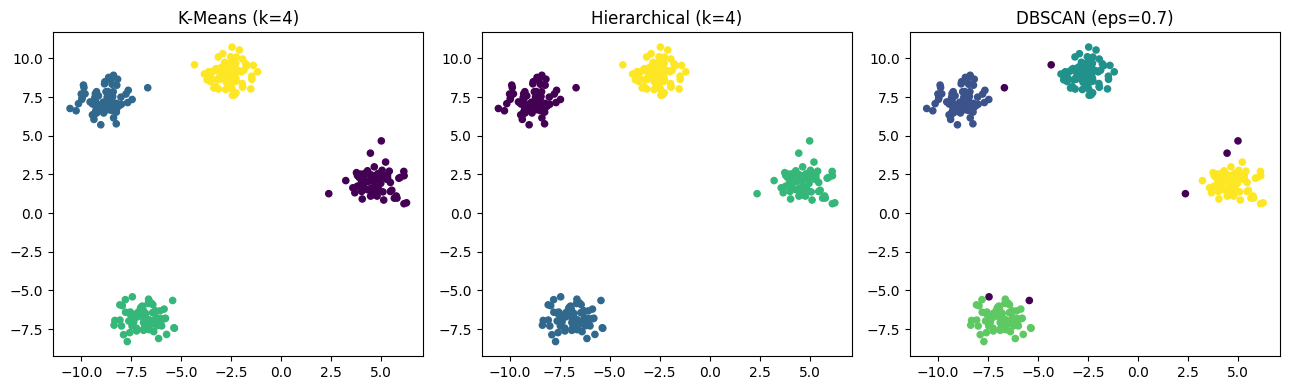

In [32]:
## All three on the same dataset — side by side
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)

models = {
    'K-Means (k=4)'      : KMeans(n_clusters=4, n_init=10, random_state=42),
    'Hierarchical (k=4)' : AgglomerativeClustering(n_clusters=4, linkage='ward'),
    'DBSCAN (eps=0.7)'   : DBSCAN(eps=0.7, min_samples=5),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, model) in zip(axes, models.items()):
    labels = model.fit_predict(X)
    ax.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=20)
    ax.set_title(name)
plt.tight_layout(); plt.show()

### What this code does
- Runs **K-Means**, **Hierarchical (ward)**, and **DBSCAN** on the same 4-blob dataset.
- All three should find roughly the same 4 groups here because the blobs are well-separated and round — the easy case.
- The real differences show up on harder data (moons, noisy points, different densities) — refer back to the comparison table to know which one to pick.